In [1]:
import numpy as np
import discretize
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../../../../"))

from Forward.MT3D import compute_mt_impedance_tipper
from Forward.utils import apparent_resistivity
from Forward.utils import phase_deg
from discretize import TensorMesh


write_output = False

import torch

In [3]:
# 1) Modelo (Δσ)
# El NPY trae contraste de conductividad Δσ en S/m 

# Frecuencias en las que se va a hacer el modelado
frequency_list = np.logspace(-4, 2, 20)

# Ubicación del receptor para el modelado
receivers = np.array([
    [0.0, 0.0, -53.7]
])

# Carga de la malla usada para el modelo 3D de conductividad 
mesh = discretize.utils.load_mesh("../../../../models/Toy7/mesh_Toy7_MT.json")

# Carga del modelo 3D de conductividad
sigma = np.load("../../../../models/Toy7/model_Toy7_MT.npy", allow_pickle=True)

print("mesh =", mesh)
print("mesh.nC=", mesh.nC)
print("mesh.nEx=", mesh.nEx)
print("mesh.nEy=", mesh.nEy)
print("mesh.nEz=", mesh.nEz)
print("frequency_list =", frequency_list)
print("receivers =", receivers)

mesh = 
  TensorMesh: 27,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   y     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   z     30     -9,000.00      5,000.00    200.00  1,000.00    5.00


mesh.nC= 27000
mesh.nEx= 28830
mesh.nEy= 28830
mesh.nEz= 28830
frequency_list = [1.00000000e-04 2.06913808e-04 4.28133240e-04 8.85866790e-04
 1.83298071e-03 3.79269019e-03 7.84759970e-03 1.62377674e-02
 3.35981829e-02 6.95192796e-02 1.43844989e-01 2.97635144e-01
 6.15848211e-01 1.27427499e+00 2.63665090e+00 5.45559478e+00
 1.12883789e+01 2.33572147e+01 4.83293024e+01 1.00000000e+02]
receivers = [[  0.    0.  -53.7]]


In [4]:
mesh

TensorMesh: 27,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   y     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   z     30     -9,000.00      5,000.00    200.00  1,000.00    5.00

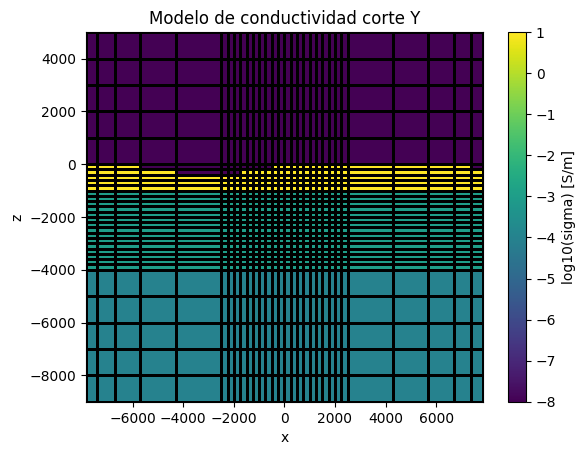

In [5]:
# 2) Plot del modelo de conductividad 3D
collect_obj = mesh.plot_slice(np.log10(sigma), grid=True, normal="Y")[0]
plt.colorbar(collect_obj, label="log10(sigma) [S/m]")
plt.title("Modelo de conductividad corte Y")
plt.savefig(f"Modelo_3D_conductividad.png", dpi=300)
plt.show()

In [6]:
# 3) Forward
Z, T = compute_mt_impedance_tipper(mesh, sigma, receivers, frequency_list)

## Se guardan el tensor de impedancias y el tipper
np.save("impedance_Toy7.npy", Z)
np.save("tipper_Toy7.npy", T)

## Se imprimen los resultados obtenidos
print("Computed shapes -> Z:", Z.shape, "T:", T.shape)

for i, r in enumerate(receivers):
    for j, f in enumerate(frequency_list):
        print(
            f"Rec {i} {r}, f={f} Hz -> "
            f"Zxy={Z[i,j,0,1]:.4e}, Zyx={Z[i,j,1,0]:.4e}, "
            f"Tzx={T[i,j,0]:.4e}, Tzy={T[i,j,1]:.4e}"
        )

Resolviendo para la frecuencia 0 de 20
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 1 de 20
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 2 de 20
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 3 de 20
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 4 de 20
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 5 de 20
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 6 de 20
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 7 de 20
calculando la impedancia en el receptor   0/1 at [  0.    

In [7]:
# Resistividad y fase aparente 
## Tensor de impedancias
Zxx = Z[:, :, 0, 0]
Zxy = Z[:, :, 0, 1]
Zyx = Z[:, :, 1, 0]
Zyy = Z[:, :, 1, 1]

rhoxx = apparent_resistivity(Zxx, frequency_list)
rhoxy = apparent_resistivity(Zxy, frequency_list)
rhoyx = apparent_resistivity(Zyx, frequency_list)
rhoyy = apparent_resistivity(Zyy, frequency_list)

phixx = phase_deg(Zxx)
phixy = phase_deg(Zxy)
phiyx = phase_deg(Zyx)
phiyy = phase_deg(Zyy)

# Tipper
Tzx=T[:,:,0]
Tzy=T[:,:,1]

Tmzx = np.abs(Tzx)
Tmzy = np.abs(Tzy)

Tpzx = phase_deg(Tzx)
Tpzy = phase_deg(Tzy)

print("Zxy:", Z[:, :, 0, 1])
print("Zyx:", Z[:, :, 1, 0])
print("Zxx:", Z[:, :, 0, 0])
print("Zyy:", Z[:, :, 1, 1])
print("Tzx:", T[:, :, 0])
print("Tzy:", T[:, :, 1])
print("|Tzx|:", Tmzx[:])
print("|Tzy|:", Tmzy[:])
print("Tzx°:", Tpzx[:])
print("Tzy°:", Tpzy[:])

Zxy: [[-7.76052321e-06-7.62936372e-06j -1.11994196e-05-1.08810090e-05j
  -1.62039936e-05-1.54152458e-05j -2.35248996e-05-2.15554225e-05j
  -3.41857100e-05-2.93683816e-05j -4.89506649e-05-3.81866793e-05j
  -6.63283788e-05-4.72537848e-05j -8.08072012e-05-6.03095959e-05j
  -8.82483555e-05-9.75943211e-05j -1.16759137e-04-1.89460344e-04j
  -2.12184578e-04-3.18214341e-04j -3.29548531e-04-4.61865867e-04j
  -4.39793767e-04-7.51172355e-04j -6.45653791e-04-1.36221931e-03j
  -1.32257850e-03-2.58637090e-03j -3.95409564e-03-3.94572015e-03j
  -7.48349953e-03-1.27272173e-03j -6.28789440e-03+2.36200784e-03j
  -3.70664785e-03+3.62608460e-03j -1.08919242e-03+3.49772490e-03j]]
Zyx: [[1.41279735e-05+1.29059298e-05j 2.03037156e-05+1.77891011e-05j
  2.91228795e-05+2.39867520e-05j 4.15363866e-05+3.12197579e-05j
  5.82986476e-05+3.83582823e-05j 7.84997096e-05+4.32487087e-05j
  9.70380717e-05+4.55161955e-05j 1.06532142e-04+5.37636328e-05j
  1.06950327e-04+9.18511118e-05j 1.29284147e-04+1.91116452e-04j
  2.2633

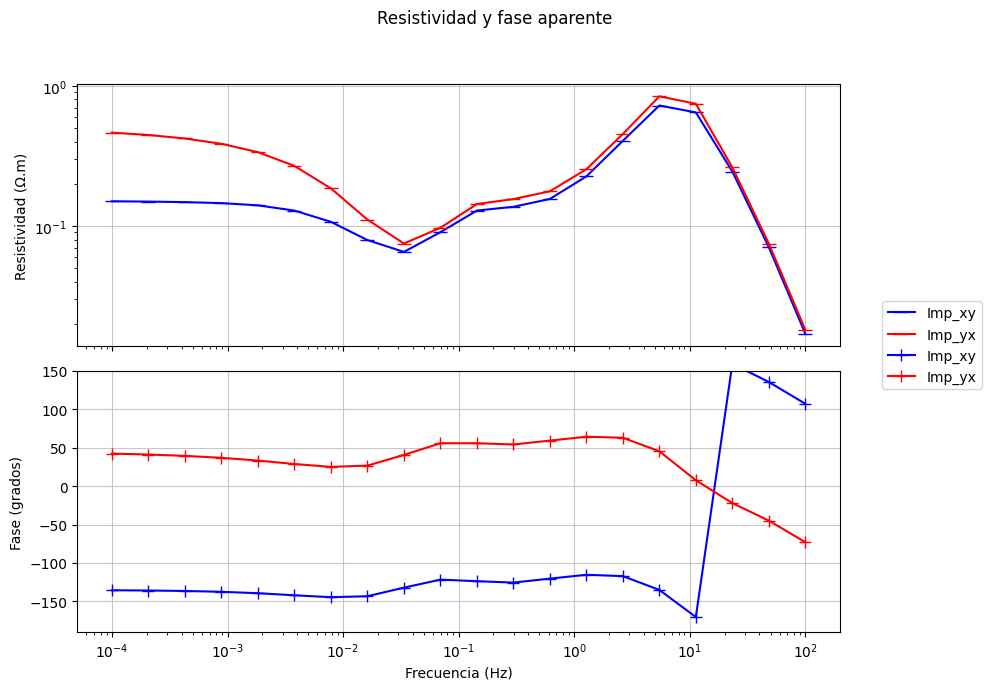

In [8]:
# 4) Plot 
#  Resistividad y fase aparente
frec = frequency_list

# Receptor a graficar
irec = 0 

# Colores por componente
c_xx = "green"
c_xy = "blue"
c_yx = "red"
c_yy = "gold"

fig, (ax_rho, ax_phi) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Resistividad
ax_rho.plot(frec, rhoxy[irec, :], marker="_", linestyle="-", color=c_xy, markersize=10, label="Imp_xy")
ax_rho.plot(frec, rhoyx[irec, :], marker="_", linestyle="-", color=c_yx, markersize=10, label="Imp_yx")

ax_rho.set_xscale("log")
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad (Ω.m)")
ax_rho.grid(True, which="major", alpha=0.7)

# Fase
ax_phi.plot(frec, phixy[irec, :], marker="+", linestyle="-", color=c_xy, markersize=8, label="Imp_xy")
ax_phi.plot(frec, phiyx[irec, :], marker="+", linestyle="-", color=c_yx, markersize=8, label="Imp_yx")

ax_phi.set_xscale("log")
ax_phi.set_xlabel("Frecuencia (Hz)")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.grid(True, which="major", alpha=0.7)
ax_phi.set_ylim(-190, 150)

handles_rho, labels_rho = ax_rho.get_legend_handles_labels()
handles_phi, labels_phi = ax_phi.get_legend_handles_labels()

fig.legend(
    handles_rho + handles_phi,
    labels_rho + labels_phi,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5)
)

fig.suptitle(f"Resistividad y fase aparente")

plt.tight_layout(rect=[0, 0, 0.86, 0.95])
plt.savefig(f"Modeling_Toy7.png", dpi=300)
plt.show()


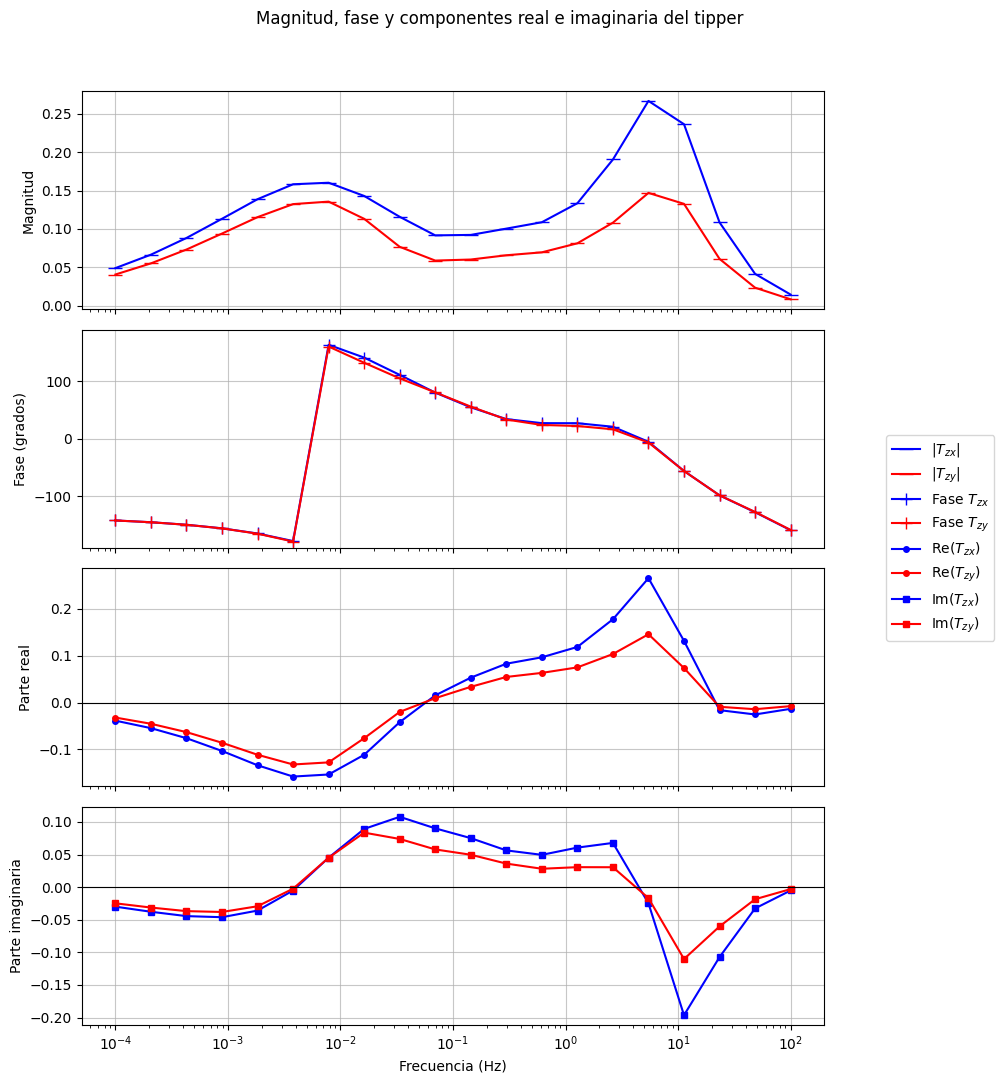

In [9]:
# Magnitud, fase, parte real e imaginaria del tipper
Tmzx = np.abs(Tzx)
Tmzy = np.abs(Tzy)

Tpzx = phase_deg(Tzx)
Tpzy = phase_deg(Tzy)

Tzx_real = np.real(Tzx)
Tzx_imag = np.imag(Tzx)

Tzy_real = np.real(Tzy)
Tzy_imag = np.imag(Tzy)

frec = frequency_list
irec = 0

# Colores por componente
c_tzx = "blue"
c_tzy = "red"

fig, (ax_mag, ax_phi, ax_real, ax_imag) = plt.subplots(
    4, 1,
    figsize=(10, 11),
    sharex=True
)

# Magnitud del tipper
ax_mag.plot(
    frec, Tmzx[irec, :],
    marker="_", linestyle="-",
    color=c_tzx, markersize=10,
    label=r"$|T_{zx}|$"
)

ax_mag.plot(
    frec, Tmzy[irec, :],
    marker="_", linestyle="-",
    color=c_tzy, markersize=10,
    label=r"$|T_{zy}|$"
)

ax_mag.set_xscale("log")
ax_mag.set_ylabel("Magnitud")
ax_mag.grid(True, which="major", alpha=0.7)

# Fase del tipper
ax_phi.plot(
    frec, Tpzx[irec, :],
    marker="+", linestyle="-",
    color=c_tzx, markersize=8,
    label=r"Fase $T_{zx}$"
)

ax_phi.plot(
    frec, Tpzy[irec, :],
    marker="+", linestyle="-",
    color=c_tzy, markersize=8,
    label=r"Fase $T_{zy}$"
)

ax_phi.set_xscale("log")
ax_phi.set_ylabel("Fase (grados)")
ax_phi.grid(True, which="major", alpha=0.7)
ax_phi.set_ylim(-190, 190)

# Parte real
ax_real.plot(
    frec, Tzx_real[irec, :],
    marker="o", linestyle="-",
    color=c_tzx, markersize=4,
    label=r"Re($T_{zx}$)"
)

ax_real.plot(
    frec, Tzy_real[irec, :],
    marker="o", linestyle="-",
    color=c_tzy, markersize=4,
    label=r"Re($T_{zy}$)"
)

ax_real.set_xscale("log")
ax_real.set_ylabel("Parte real")
ax_real.grid(True, which="major", alpha=0.7)
ax_real.axhline(0, color="black", linewidth=0.8)

# Parte imaginaria
ax_imag.plot(
    frec, Tzx_imag[irec, :],
    marker="s", linestyle="-",
    color=c_tzx, markersize=4,
    label=r"Im($T_{zx}$)"
)

ax_imag.plot(
    frec, Tzy_imag[irec, :],
    marker="s", linestyle="-",
    color=c_tzy, markersize=4,
    label=r"Im($T_{zy}$)"
)

ax_imag.set_xscale("log")
ax_imag.set_xlabel("Frecuencia (Hz)")
ax_imag.set_ylabel("Parte imaginaria")
ax_imag.grid(True, which="major", alpha=0.7)
ax_imag.axhline(0, color="black", linewidth=0.8)


handles, labels = [], []

for ax in [ax_mag, ax_phi, ax_real, ax_imag]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5)
)

fig.suptitle("Magnitud, fase y componentes real e imaginaria del tipper")

plt.tight_layout(rect=[0, 0, 0.84, 0.95])
plt.savefig("Tipper_ModelingToy7.png", dpi=300)
plt.show()